# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-23 13:48:44.926075: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/leoxie/Desktop/tinyml_env_setup_package/UCI HAR Dataset


## 3. Load the Data


In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test  = np.loadtxt(root_dir / "test"  / "X_test.txt",  dtype=np.float32)
    y_test  = np.loadtxt(root_dir / "test"  / "y_test.txt",  dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:
def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:
teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/20
92/92 [==

### Teacher Training Curves


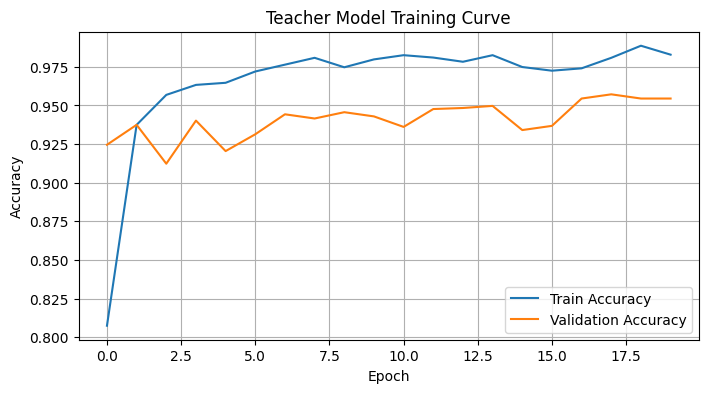

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [8]:
student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - loss: 0.6947 - accuracy: 0.7674 - val_loss: 0.3262 - val_accuracy: 0.8906
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - loss: 0.2689 - accuracy: 0.9078 - val_loss: 0.2485 - val_accuracy: 0.9137
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1705 - accuracy: 0.9441 - val_loss: 0.2348 - val_accuracy: 0.9157
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - loss: 0.1358 - accuracy: 0.9534 - val_loss: 0.1561 - val_accuracy: 0.9320
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1074 - accuracy: 0.9621 - val_loss: 0.1495 - val_accuracy: 0.9279
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0854 - accuracy: 0.9725 - val_loss: 0.2112 - val_accuracy: 0.9293
Epoch 7/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0778 - accuracy: 0.9747 - val_loss: 0.1267 - val_accuracy: 0.9436
Epoch 8/20
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - loss: 0.0791 - accuracy: 0.9716 - val_loss: 0.1453 - val_accuracy: 0.9395
Epoch 2/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0684 - accuracy: 0.9753 - val_loss: 0.1433 - val_accuracy: 0.9429
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0545 - accuracy: 0.9818 - val_loss: 0.1628 - val_accuracy: 0.9436
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0579 - accuracy: 0.9796 - val_loss: 0.1391 - val_accuracy: 0.9463
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0540 - accuracy: 0.9804 - val_loss: 0.1319 - val_accuracy: 0.9470
Epoch 6/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0460 - accuracy: 0.9842 - val_loss: 0.1579 - val_accuracy: 0.9483
Epoch 7/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0679 - accuracy: 0.9755 - val_loss: 0.1676 - val_accuracy: 0.9422
Epoch 8/20
92/92 [==

### Baseline Student Training Curves


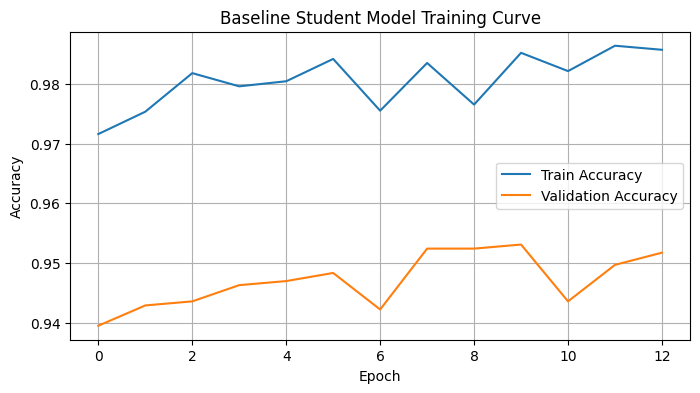

In [10]:
student_baseline_history_df = pd.DataFrame(student_baseline_history.history)

plt.figure(figsize=(8, 4))
plt.plot(student_baseline_history_df["accuracy"], label="Train Accuracy")
plt.plot(student_baseline_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Student Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 9. Evaluate the Baseline Student Model


In [11]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(tf.math.log(teacher_predictions + 1e-9) / self.temperature, axis=1),
                tf.nn.softmax(tf.math.log(student_predictions + 1e-9) / self.temperature, axis=1),
            ) * (self.temperature ** 2)

            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [12]:
distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1,
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - accuracy: 0.6385 - student_loss: 0.8197 - distillation_loss: 8.6124 - val_accuracy: 0.8042 - val_student_loss: 0.2315
Epoch 2/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.8652 - student_loss: 0.3175 - distillation_loss: 2.3557 - val_accuracy: 0.9361 - val_student_loss: 6.1037e-04
Epoch 3/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9145 - student_loss: 0.2000 - distillation_loss: 1.1381 - val_accuracy: 0.9415 - val_student_loss: 9.5277e-05
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9391 - student_loss: 0.1448 - distillation_loss: 0.7275 - val_accuracy: 0.9470 - val_student_loss: 2.4035e-04
Epoch 5/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9532 - student_loss: 0.1116 - distillation_loss: 0.4895 - val_accuracy: 0.9463 - val_student_loss: 9.0147e-05
Epoch 6/20
92/92 [==============================] - 0s 2ms/step 

## 11. Train the Distilled Student


In [13]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - accuracy: 0.6642 - student_loss: 0.7480 - distillation_loss: 7.8099 - val_accuracy: 0.8708 - val_student_loss: 0.0367
Epoch 2/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.8951 - student_loss: 0.2489 - distillation_loss: 1.8298 - val_accuracy: 0.9014 - val_student_loss: 1.5047e-04
Epoch 3/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9330 - student_loss: 0.1620 - distillation_loss: 0.8291 - val_accuracy: 0.9395 - val_student_loss: 1.3412e-04
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9527 - student_loss: 0.1157 - distillation_loss: 0.5243 - val_accuracy: 0.9497 - val_student_loss: 2.1426e-04
Epoch 5/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.9662 - student_loss: 0.0863 - distillation_loss: 0.3309 - val_accuracy: 0.9517 - val_student_loss: 2.5907e-04
Epoch 6/20
92/92 [==============================] - 0s 2ms/step 

### Distillation Training Curves


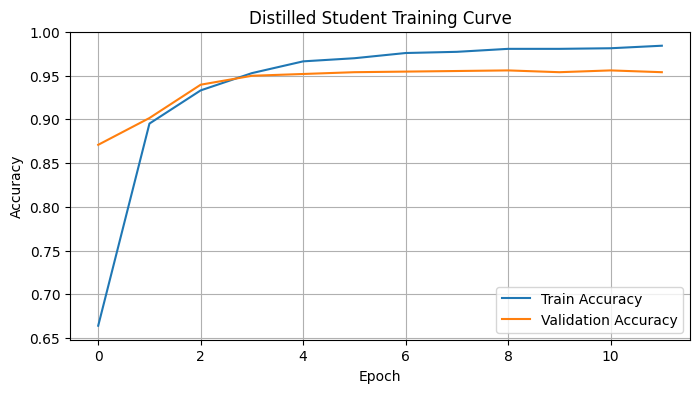

In [14]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9345

                    precision    recall  f1-score   support

           WALKING     0.8903    0.9819    0.9338       496
  WALKING_UPSTAIRS     0.9422    0.9002    0.9207       471
WALKING_DOWNSTAIRS     0.9719    0.9071    0.9384       420
           SITTING     0.9409    0.8758    0.9072       491
          STANDING     0.8798    0.9492    0.9132       532
            LAYING     1.0000    0.9814    0.9906       537

          accuracy                         0.9345      2947
         macro avg     0.9375    0.9326    0.9340      2947
      weighted avg     0.9368    0.9345    0.9346      2947



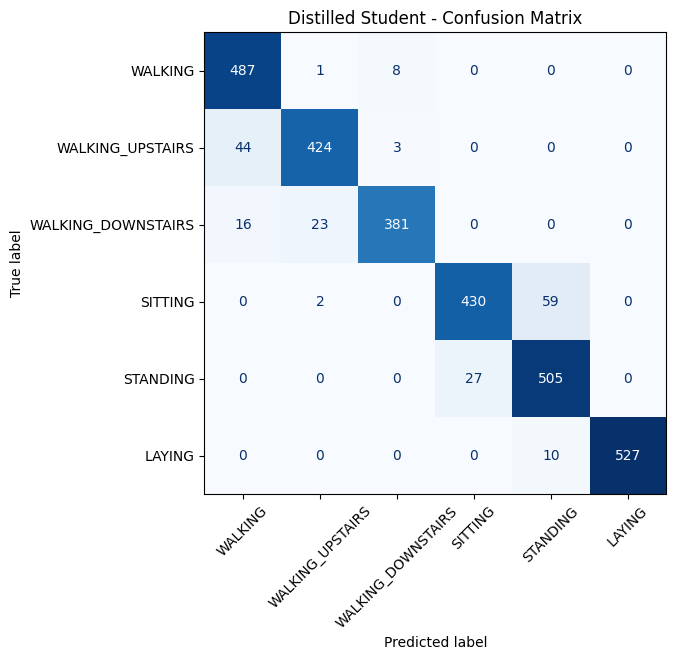

In [15]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


            Model  Parameters  Test Accuracy
    Teacher Model      185414       0.931795
 Baseline Student       38246       0.920937
Distilled Student       38246       0.934510


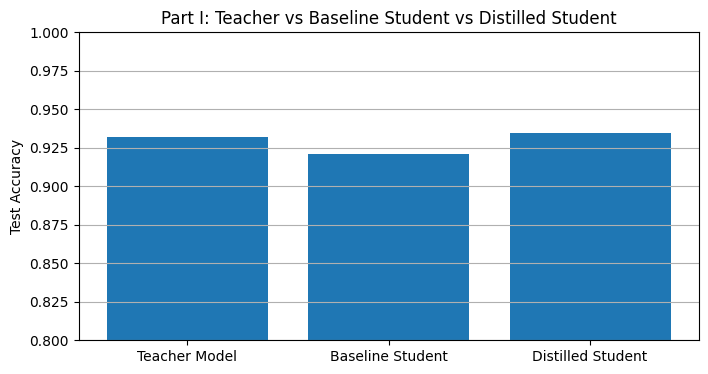

In [16]:
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
teacher_acc = accuracy_score(y_test, teacher_preds)

student_baseline_probs = student_baseline_model.predict(X_test, verbose=0)
student_baseline_preds = np.argmax(student_baseline_probs, axis=1)
student_baseline_acc = accuracy_score(y_test, student_baseline_preds)

# distilled_acc / distilled_preds were computed in Section 12.
part1_results = pd.DataFrame([
    ["Teacher Model",     teacher_model.count_params(),          teacher_acc],
    ["Baseline Student",  student_baseline_model.count_params(), student_baseline_acc],
    ["Distilled Student", distilled_student.count_params(),      distilled_acc],
], columns=["Model", "Parameters", "Test Accuracy"])

print(part1_results.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(part1_results["Model"], part1_results["Test Accuracy"])
plt.ylim(0.80, 1.00)
plt.ylabel("Test Accuracy")
plt.title("Part I: Teacher vs Baseline Student vs Distilled Student")
plt.grid(axis="y")
plt.show()


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [17]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [18]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 TFLite Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 TFLite Size (KB): {distilled_fp32_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp_2_glvze/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp_2_glvze/assets
2026-04-23 13:49:09.892802: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 13:49:09.892819: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 13:49:09.893152: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp_2_glvze
2026-04-23 13:49:09.893856: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 13:49:09.893871: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp_2_glvze
2026-04-23 13:49:09.895308: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 13:49:09.895800: I tensorflow/cc/saved_model/load

Distilled Student FP32 TFLite Accuracy: 0.9345
Distilled Student FP32 TFLite Size (KB): 151.51


In [19]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/10
92/92 [==============================] - 2s 3ms/step - loss: 0.0458 - accuracy: 0.9840 - val_loss: 0.0999 - val_accuracy: 0.9551
Epoch 2/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0530 - accuracy: 0.9821 - val_loss: 0.1041 - val_accuracy: 0.9531
Epoch 3/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0666 - accuracy: 0.9782 - val_loss: 0.1077 - val_accuracy: 0.9545
Epoch 4/10
92/92 [==============================] - 0s 2ms/step - loss: 0.1122 - accuracy: 0.9645 - val_loss: 0.1288 - val_accuracy: 0.9504


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [20]:
# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp9eoe5sr4/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp9eoe5sr4/assets
2026-04-23 13:49:14.403906: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 13:49:14.403924: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 13:49:14.404094: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp9eoe5sr4
2026-04-23 13:49:14.407013: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 13:49:14.407024: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp9eoe5sr4
2026-04-23 13:49:14.415053: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 13:49:14.457685: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpztor_8mv/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpztor_8mv/assets
2026-04-23 13:49:15.022247: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 13:49:15.022263: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 13:49:15.022414: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpztor_8mv
2026-04-23 13:49:15.022926: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 13:49:15.022936: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpztor_8mv
2026-04-23 13:49:15.024161: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 13:49:15.037986: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned distilled model with mask accuracy: 0.9376
Pruned distilled model with mask size (KB): 154.46
Stripped sparse distilled model accuracy: 0.9376
Stripped sparse distilled model size (KB): 151.51


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [21]:
# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8i33l887/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8i33l887/assets
/Users/leoxie/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 13:49:15.507324: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 13:49:15.507349: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 13:49:15.507597: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8i33l887
2026-04-23 13:49:15.508253: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 13:49:15.508265: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn0

Stripped Sparse + INT8 Accuracy: 0.9386
Stripped Sparse + INT8 Size (KB): 40.15


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [22]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpng5_e89w/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpng5_e89w/assets
/Users/leoxie/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 13:49:16.422834: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 13:49:16.422850: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 13:49:16.423005: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpng5_e89w
2026-04-23 13:49:16.423510: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 13:49:16.423519: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn0

Stripped Sparse + INT8 Accuracy: 0.9386
Stripped Sparse + INT8 Size (KB): 40.15


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [23]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.934510,151.511719
1,Pruned Distilled TFLite (with mask),FP32,0.937564,154.464844
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.937564,151.511719
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.938582,40.148438


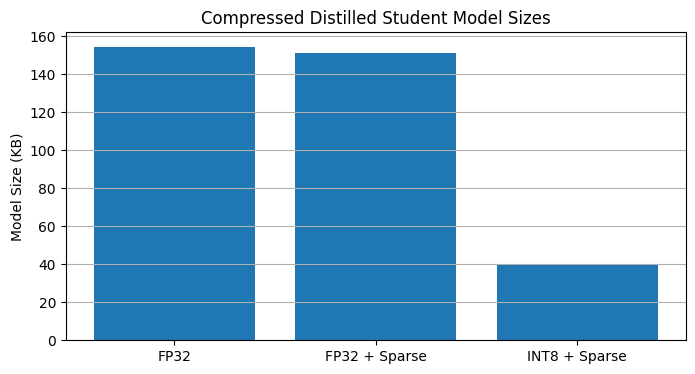

In [24]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


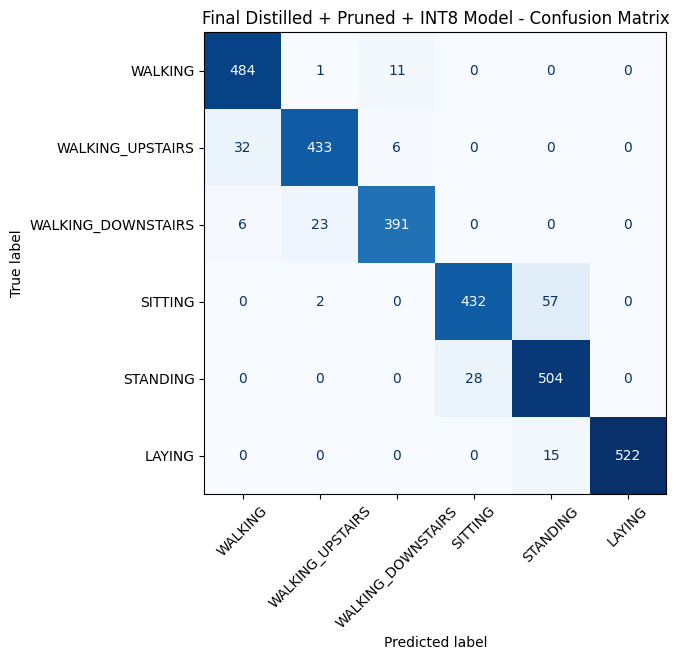

In [25]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?

**Baseline student actually performed a bit worse than distilled student.**

2. Did **knowledge distillation** help the smaller model retain performance?

**Yes, distillation does help the smaller model retain performance.**

3. What happened to the model size after **pruning** and after **INT8 quantization**?

**Prunning did not change the model size much but INT 8 quantization reduced the model size down from 151 kB to 40 kB.**

4. Which model would you choose for **Arduino deployment**, and why?

**For Arduino deployment, I would choose the distilled student after INT8 quantization for it's reduced size and retained performance.**

5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?

**The final sparse INT8 model is a good TinyML deployment candidate because it has a small size and good relative performance.**


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
